# 분류 실습 - 캐글 산탄데로 고객 만족 예측

## Data Preprocessing

In [ ]:
# Importing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Load dataset
cust_df = pd.read_csv("santander-customer-satisfaction/train.csv",encoding='latin-1')
print('dataset shape:',cust_df.shape)
cust_df.head()

# Features 370 + Label 1
# Rows(Data) 76020

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [7]:
cust_df.info()

# all features are float & int type
cust_df.iloc[:,-1] # Checking label name : TARGET

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


0        0
1        0
2        0
3        0
4        0
        ..
76015    0
76016    0
76017    0
76018    0
76019    0
Name: TARGET, Length: 76020, dtype: int64

In [ ]:
# Label's Distribution
print(cust_df['TARGET'].value_counts())
unsatisfied_cnt = cust_df[cust_df['TARGET']==1].TARGET.count() #3008
total_cnt = cust_df.TARGET.count() #76020
print('unsatisfied 비율은 {0:.2f}'.format(unsatisfied_cnt/total_cnt)) #0.04

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.04


In [ ]:
cust_df.describe() 
# min of var3 : -999999 which is too deviated from other values 
cust_df.var3.value_counts() # 116개의 -999999
# replace it with 2(가장 많은 값)

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
           ...  
 231           1
 188           1
 168           1
 135           1
 87            1
Name: count, Length: 208, dtype: int64

In [ ]:
# Data Preprocessing
# Replacing var3 -999999 with 2
# drop ID (just identifier no meaning)
cust_df['var3'].replace(-999999,2,inplace=True)
cust_df.drop('ID',axis=1,inplace=True)

In [19]:
# Split into Feature Set & Label Set
X_features = cust_df.iloc[:,:-1]
y_labels = cust_df.iloc[:,-1]
print('피처 데이터 shape:{0}'.format(X_features.shape))
print('레이블 데이터 shape:{0}'.format(y_labels.shape))

피처 데이터 shape:(76020, 370)
레이블 데이터 shape:(76020,)


In [20]:
# Splitting into Train & Test dataset (80:20)
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X_features,y_labels,test_size=0.2,random_state=0)

In [32]:
# Imbalanced Dataset -> Checking whether label(target) data is similarly distributed in Train & Test dataset

train_cnt = y_train.count() #60816
test_cnt = y_test.count() #15204
print("학습 세트 Shape:{0}, 테스트 세트 Shape:{1}".format(X_train.shape,X_test.shape))

print('학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt)
print('테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/test_cnt)

# Train & Test data of 1(불만족) got distributed similarly as original label data : ~0.4

학습 세트 Shape:(60816, 370), 테스트 세트 Shape:(15204, 370)
학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64
테스트 세트 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


In [33]:
# Split Train dataset into Train & Validation set for XGBoost early stopping round (70:30)

X_tr,X_val,y_tr,y_val = train_test_split(X_train,y_train,test_size=0.3,random_state=0)

## XGBoost Model Training & Hyper Parameter Tuning

In [37]:
# Model Training
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
# For early_stopping_round, 
    # eval_set
    # eval_metric
    # cuz it have to stops training if metric doesn't improve on the validation set

# Train
# n_estimators : number of trees(boosting_rounds) used in the ensemble
# eval_metric : auc cuz will be using roc_auc_score
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05, early_stopping_rounds=100, eval_metric='auc', random_state=156)
xgb_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)],verbose=False)

# Evaluate
# roc_auc_score need probability so have to use predict_proba
xgb_roc_score = roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

ROC AUC: 0.8392


In [38]:
# Hyper Parameter Tuning (based on Bayesian Optimization using HyperOpt)
from hyperopt import hp

# Setting search space
# int : max_depth(5 to 15 with gap 1), min_child_weight(1 to 6 with gap 1)
# float : colsample_bytree(0.5 to 0.95 with normal distribution), learning_rate(0.01 to 0.2 with normal distribution)
xgb_search_space = {'max_depth':hp.quniform('max_depth',5,15,1),
                    'min_child_weight':hp.quniform('min_child_weight',1,6,1),
                    'colsample_bytree': hp.uniform('colsample_bytree',0.5,0.95),
                    'learning_rate':hp.uniform('learning_rate',0.01,0.2)
                    }

In [57]:
# Setting Objective Function
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
def objective_function(search_space):
    # make n_estimators to 100 & early_stopping round to 30 to reduce operation time
    # max_depth and min_child_weight should be changed into int as all return types of search_sapce is float
    xgb_clf = XGBClassifier(n_estimators=100,early_stopping_rounds=30,eval_metric='auc',
                            max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytree=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate']
                            )
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    roc_auc_list = []

    kf = KFold(n_splits=3)
    for tr_index,val_index in kf.split(X_train):
        # Split
        X_tr,y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val,y_val = X_train.iloc[val_index], y_train.iloc[val_index]
        # Train
        xgb_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])
        # Evaluate
        score = roc_auc_score(y_val,xgb_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

    # objective function need mean value while roc_auc_score give max so multiply with -1
    return -1*np.mean(roc_auc_list)

In [58]:
# Extract optimized hyper parameters
from hyperopt import fmin,tpe,Trials

# stores results of each run
trials = Trials()

# fmin() : return best-performing parameter combination
# max_evals : number of diff parameter combinations(trials) to try
best = fmin(fn=objective_function,space=xgb_search_space,algo=tpe.suggest,max_evals=50,trials=trials,rstate=np.random.default_rng(seed=30))
print('best:',best)

[0]	validation_0-auc:0.84615	validation_1-auc:0.81197 
[1]	validation_0-auc:0.85175	validation_1-auc:0.81707 
[2]	validation_0-auc:0.85635	validation_1-auc:0.82176 
[3]	validation_0-auc:0.85848	validation_1-auc:0.82339 
[4]	validation_0-auc:0.86047	validation_1-auc:0.82534 
[5]	validation_0-auc:0.86189	validation_1-auc:0.82681 
[6]	validation_0-auc:0.86273	validation_1-auc:0.82723 
[7]	validation_0-auc:0.86570	validation_1-auc:0.82948 
[8]	validation_0-auc:0.86737	validation_1-auc:0.82924 
[9]	validation_0-auc:0.86779	validation_1-auc:0.82988 
[10]	validation_0-auc:0.86872	validation_1-auc:0.83146
[11]	validation_0-auc:0.87039	validation_1-auc:0.83153
[12]	validation_0-auc:0.87210	validation_1-auc:0.83158
[13]	validation_0-auc:0.87341	validation_1-auc:0.83241
[14]	validation_0-auc:0.87468	validation_1-auc:0.83305
[15]	validation_0-auc:0.87552	validation_1-auc:0.83309
[16]	validation_0-auc:0.87632	validation_1-auc:0.83305
[17]	validation_0-auc:0.87700	validation_1-auc:0.83364
[18]	valid

In [59]:
# Retrain again with optimal hyper parameters
xgb_clf = XGBClassifier(n_estimators=500, early_stopping_rounds=100, eval_metric="auc",
                        max_depth=int(best['max_depth']),
                        min_child_weight=int(best['min_child_weight']),
                        colsample_bytree=round(best['colsample_bytree'],5),
                        learning_rate=round(best['learning_rate'],5)
                        )
xgb_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])
xgb_roc_score = roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.77397	validation_1-auc:0.73911
[1]	validation_0-auc:0.83844	validation_1-auc:0.80921
[2]	validation_0-auc:0.83438	validation_1-auc:0.79997
[3]	validation_0-auc:0.84701	validation_1-auc:0.81858
[4]	validation_0-auc:0.85174	validation_1-auc:0.82449
[5]	validation_0-auc:0.85525	validation_1-auc:0.82631
[6]	validation_0-auc:0.85580	validation_1-auc:0.82434
[7]	validation_0-auc:0.85507	validation_1-auc:0.82396
[8]	validation_0-auc:0.85781	validation_1-auc:0.82738
[9]	validation_0-auc:0.85976	validation_1-auc:0.83006
[10]	validation_0-auc:0.85938	validation_1-auc:0.82969
[11]	validation_0-auc:0.86127	validation_1-auc:0.83155
[12]	validation_0-auc:0.86410	validation_1-auc:0.83335
[13]	validation_0-auc:0.86623	validation_1-auc:0.83362
[14]	validation_0-auc:0.86667	validation_1-auc:0.83355
[15]	validation_0-auc:0.86831	validation_1-auc:0.83465
[16]	validation_0-auc:0.86968	validation_1-auc:0.83501
[17]	validation_0-auc:0.87075	validation_1-auc:0.83511
[18]	validation_0-au

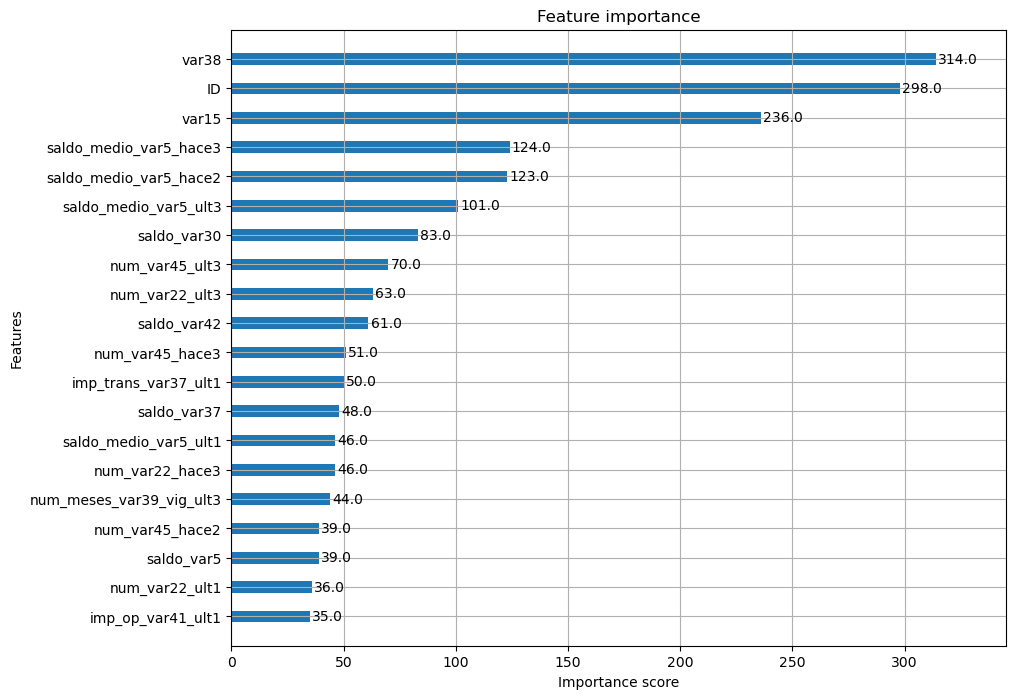

In [60]:
# Plot important features
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax = plt.subplots(1,1,figsize=(10,8))
# ; -> for suppressing return value so that the graph is not show twice
plot_importance(xgb_clf,ax=ax,max_num_features=20,height=0.4);
plt.show()

## LightGBM Model Training & Hyper Parameter Tuning

In [61]:
# Model Training
from lightgbm import LGBMClassifier,early_stopping

# Train
lgbm_clf = LGBMClassifier(n_estimators=500)
lgbm_clf.fit(X_tr,y_tr,eval_metric="auc",eval_set=[(X_tr,y_tr),(X_val,y_val)],callbacks=[early_stopping(stopping_rounds=100)])

# Evaluate
lgbm_roc_score = roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13564
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 243
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[45]	training's auc: 0.917002	training's binary_logloss: 0.110436	valid_1's auc: 0.832205	valid_1's binary_logloss: 0.135309
ROC AUC: 0.8383


In [62]:
# Hyper Parameter Tuning (based on Bayesian Optimization using HyperOpt)

# Setting search space
lgbm_search_space = {'num_leaves':hp.quniform('num_leaves',32,64,1),
                     'max_depth': hp.quniform('max_depth',100,160,1),
                     'min_child_samples': hp.quniform('min_child_samples',60,100,1),
                     'subsample': hp.uniform('subsample',0.7,1),
                     'learning_rate': hp.uniform('learning_rate',0.01,0.2)

}

In [70]:
# Setting objective function
def objective_func(search_space):
    # Train
    lgbm_clf = LGBMClassifier(n_estimators=100,
                              num_leaves=int(search_space['num_leaves']),
                              max_depth=int(search_space['max_depth']),
                              min_child_samples=int(search_space['min_child_samples']),
                              subsample=search_space['subsample'],
                              learning_rate=search_space['learning_rate']
    )
    roc_auc_list = []
    # 3 KFold                      
    kfold = KFold(n_splits=3)
    for tr_index,val_index in kfold.split(X_train):
        # Split
        X_tr,y_tr = X_train.iloc[tr_index],y_train.iloc[tr_index]
        X_val,y_val = X_train.iloc[val_index],y_train.iloc[val_index]
        # Train
        lgbm_clf.fit(X_tr,y_tr,eval_metric="auc",eval_set=[(X_tr,y_tr),(X_val,y_val)],callbacks=[early_stopping(stopping_rounds=30)])
        # Evaluate
        score = roc_auc_score(y_val,lgbm_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)
    return -1*np.mean(roc_auc_list)
        

In [71]:
# Extract optimized hyper parameters
from hyperopt import fmin,tpe,Trials
trials = Trials()
best = fmin(fn=objective_func,space=lgbm_search_space,algo=tpe.suggest,max_evals=50,trials=trials,rstate=np.random.default_rng(seed=30))
print('best: ',best)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?][LightGBM] [Info] Number of positive: 1579, number of negative: 38965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13083
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 193
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038945 -> initscore=-3.205872
[LightGBM] [Info] Start training from score -3.205872
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:       
[96]	training's auc: 0.889702	training's binary_logloss: 0.121608	valid_1's auc: 0.832336	valid_1's binary_logloss: 0.135746
  0%|          | 0/50 [00:01<?, ?trial/s, best loss=?][LightGBM] [Info] Number of positive: 1609, number of negative: 38935
[LightGBM] [Info] Auto

In [77]:
# Retrain again with optimal hyper parameters
# Train
lgbm_clf = LGBMClassifier(n_estimators=500,
                          num_leaves=int(best['num_leaves']),
                          max_depth=int(best['max_depth']),
                          min_child_samples=int(best['min_child_samples']),
                          subsample=round(best['subsample'],5),
                          learning_rate=round(best['learning_rate'],5)
)
lgbm_clf.fit(X_tr,y_tr,eval_metric="auc",eval_set=[(X_tr,y_tr),(X_val,y_val)],callbacks=[early_stopping(stopping_rounds=100)])

# Evaluate
lgbm_roc_score = roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13218
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 198
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[77]	training's auc: 0.911037	training's binary_logloss: 0.113604	valid_1's auc: 0.83633	valid_1's binary_logloss: 0.134419
ROC AUC: 0.8409


# 분류 실습 - 캐글 신용카드 사기 검출

## Undersampling and Oversampling
- Undersampling: 0: 10000, 1:100 -> decrease 0s to 100
- Oversampling: 0: 10000, 1:100 -> increase 1s to 1000

## 데이터 일차 가공 및 모델 학습/예측/평가

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

card_df = pd.read_csv('./creditcard.csv')
card_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Data Preprocessing
# Dropping Time (unrelavant)
from sklearn.model_selection import train_test_split

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

In [ ]:
# Split dataset into Train & Test
def get_train_test_dataset(df=None):
    # Data Pre-processing
    df_copy = get_preprocessed_df(df)
    # Feature
    X_features = df_copy.iloc[:, :-1]
    # Label
    y_target = df_copy.iloc[:, -1]
    # Train data(70%), Test data(30%)
    X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [ ]:
# Checking 0s & 1s distribution in Train,Test dataset
print('학습 데이터 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('테스트 데이터 레이블 값 비율')
print(y_test.value_counts()/y_test.shape[0] * 100)

학습 데이터 레이블 값 비율
Class
0    99.827451
1     0.172549
Name: count, dtype: float64
테스트 데이터 레이블 값 비율
Class
0    99.826785
1     0.173215
Name: count, dtype: float64


In [ ]:
# Using LogisticRegression
from sklearn.linear_model import LogisticRegression

# Train
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
# Predict
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]
# Evaluate
get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[85282    13]
 [   56    92]]
정확도: 0.9992, 정밀도: 0.8762, 재현율: 0.6216,    F1: 0.7273, AUC:0.9558


In [ ]:
# Make Train,Predict,Evaluate process as a function
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    # Train
    model.fit(ftr_train, tgt_train)
    # Predict
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    # Evaluate
    get_clf_eval(tgt_test, pred, pred_proba)

In [ ]:
# Using LightGBM
from lightgbm import LGBMClassifier
# Train & Evaluate
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

## 데이터 분포도 변환 후 모델 학습/예측/평가

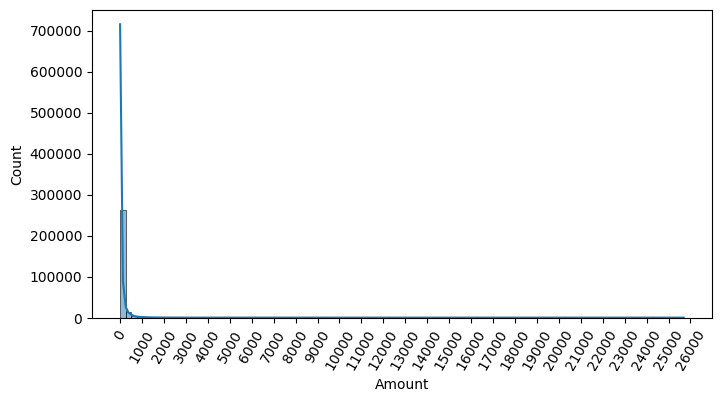

In [ ]:
# Distribution of Amount Feature (Important feature for determining Fraud)
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.histplot(card_df['Amount'], bins=100, kde=True)
plt.show()

In [ ]:
# Data Preprocessing 
# Scaling - making Amount into Normal Distribution using StandardScaler
from sklearn.preprocessing import StandardScaler
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [ ]:
# Train & Evaluate with LogisticRegression & LGBMClassifier
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('### 로지스틱 회귀 예측 성능 ###')
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print('### LightGBM 예측 성능 ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85281    14]
 [   58    90]]
정확도: 0.9992, 정밀도: 0.8654, 재현율: 0.6081,    F1: 0.7143, AUC:0.9702
### LightGBM 예측 성능 ###
오차 행렬
[[85290     5]
 [   37   111]]
정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500,    F1: 0.8409, AUC:0.9779


In [ ]:
# Data Pre-processing
# Scaling - changing Amount into log
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [ ]:
# Train & Evaluate with LogisticRegression & LGBMClassifier
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85283    12]
 [   59    89]]
정확도: 0.9992, 정밀도: 0.8812, 재현율: 0.6014,    F1: 0.7149, AUC:0.9727
### LightGBM 예측 성능 ###
오차 행렬
[[85290     5]
 [   35   113]]
정확도: 0.9995, 정밀도: 0.9576, 재현율: 0.7635,    F1: 0.8496, AUC:0.9796


## 이상치 데이터 제거 후 모델 학습/예측/평가

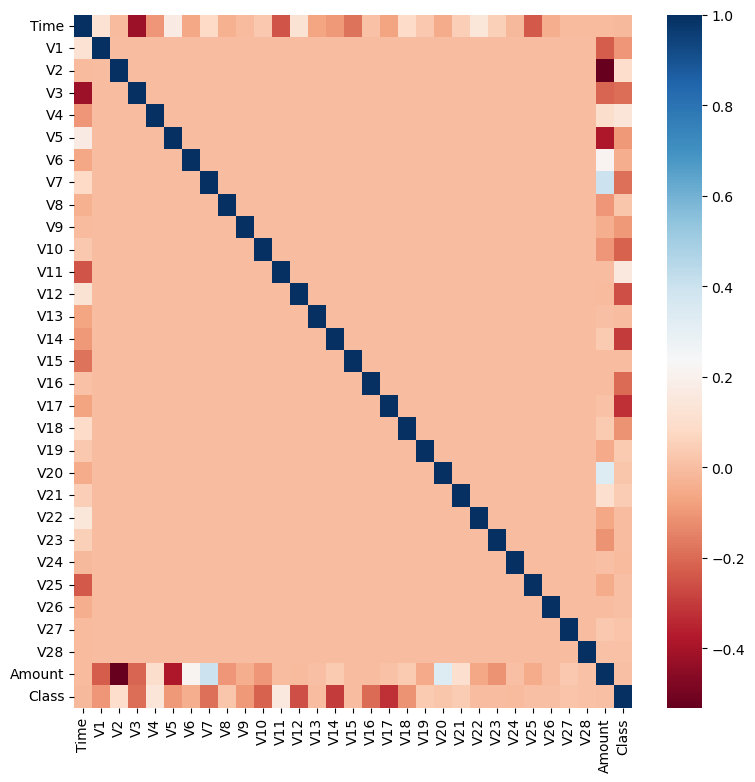

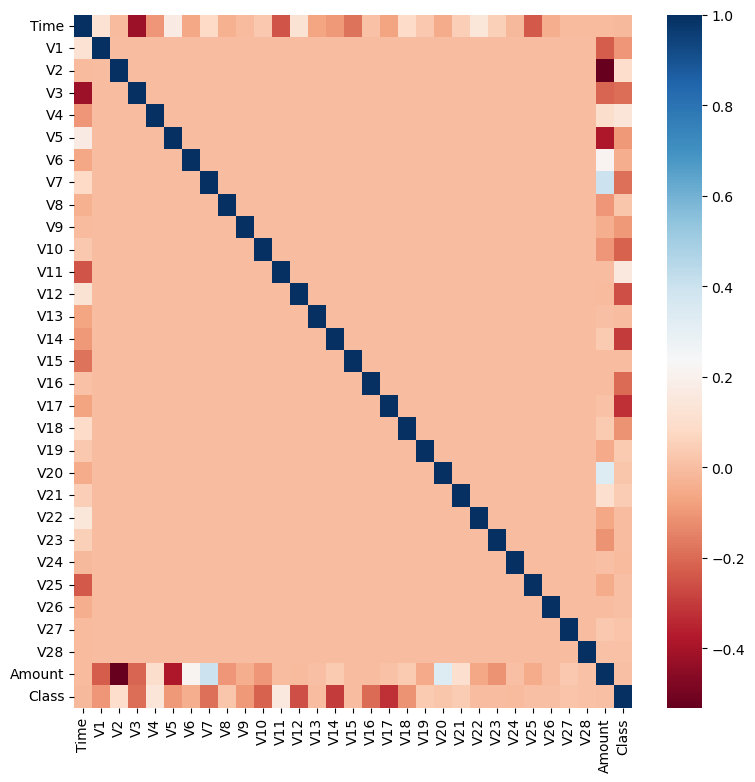

In [ ]:
# Plotting correlation
import seaborn as sns

plt.figure(figsize=(9, 9))
corr = card_df.corr()
sns.heatmap(corr, cmap='RdBu')
# Most related with class : V14, V17
plt.show()

In [ ]:
fraud = card_df[card_df['Class']==1]['V14']
fraud

541      -4.289254
623      -1.692029
4920     -1.470102
6108     -6.771097
6329     -6.079337
            ...   
279863   -6.665177
280143   -5.210141
280149   -4.057162
281144   -6.416628
281674   -1.948883
Name: V14, Length: 492, dtype: float64

In [ ]:
# Find Outliers
# iqr : Q1~Q3
# min = Q1-(iqr*weight)
# max = Q3+(iqr*weight)
# Outliers = < min and > max
import numpy as np

def get_outlier(df=None, column=None, weight=1.5):
    fraud = df[df['Class']==1][column]
    # Q1
    quantile_25 = np.percentile(fraud.values, 25)
    # Q3
    quantile_75 = np.percentile(fraud.values, 75)
    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    # min
    lowest_val = quantile_25 - iqr_weight
    # max
    highest_val = quantile_75 + iqr_weight
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index
    

In [ ]:
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
print('이상치 데이터 인덱스:', outlier_index)

이상치 데이터 인덱스: Index([8296, 8615, 9035, 9252], dtype='int64')


In [ ]:
# Data Preprocessing
# Remove outliers of V14 feature
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # add logic to remove outliers
    outlier_index = get_outlier(df=df_copy, column='V14', weight=1.5)
    df_copy.drop(outlier_index, axis=0, inplace=True)
    return df_copy

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)
print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85280    15]
 [   48    98]]
정확도: 0.9993, 정밀도: 0.8673, 재현율: 0.6712,    F1: 0.7568, AUC:0.9725
### LightGBM 예측 성능 ###
[LightGBM] [Info] Number of positive: 342, number of negative: 199020
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199362, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

## SMOTE 오버 샘플링 적용 후 모델 학습/예측/평가

In [ ]:
# Using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
# Only do oversampling on Train dataset
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 전 학습용 피처/레이블 데이터 세트: ', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 후 레이블 값 분포: \n', pd.Series(y_train_over).value_counts())
# 2배로 증식, 분포 비슷해짐

SMOTE 적용 전 학습용 피처/레이블 데이터 세트:  (199362, 29) (199362,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트:  (398040, 29) (398040,)
SMOTE 적용 후 레이블 값 분포: 
 Class
0    199020
1    199020
Name: count, dtype: int64


In [ ]:
# Train with LogisticRegression
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

오차 행렬
[[82937  2358]
 [   11   135]]
정확도: 0.9723, 정밀도: 0.0542, 재현율: 0.9247,    F1: 0.1023, AUC:0.9737


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_recall_curve
%matplotlib inline

def precision_recall_curve_plot(y_test , pred_proba_c1):
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
    
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

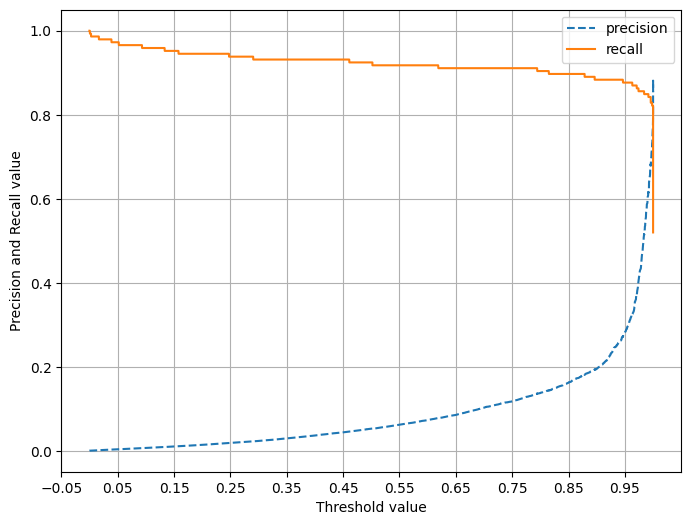

In [ ]:
# Plotting Precision vs Recall
precision_recall_curve_plot( y_test, lr_clf.predict_proba(X_test)[:, 1] )

In [ ]:
# Train Test Evaluate LightGBM with oversampling data
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test,
                  tgt_train=y_train_over, tgt_test=y_test)

오차 행렬
[[85283    12]
 [   22   124]]
정확도: 0.9996, 정밀도: 0.9118, 재현율: 0.8493,    F1: 0.8794, AUC:0.9814


# Decision Tree And Random Forest Classifier Models

## Data Review

In [ ]:
data = pd.read_csv("./drug200.csv")
data

# 200 data, 5 features + 1 label(Drug)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
# Checking information of data
data.info()

# no null, 1 float, 1 int, 4 objs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
data.describe()

# only Age(int) & Na_to_K(float) can be described

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [96]:
# Data correlation (데이터 칼럼들간의 관계)
cor = data.corr(numeric_only=True)
cor
# only numeric values can be correlated

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


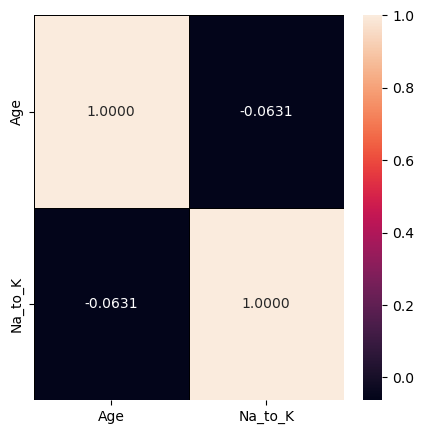

In [95]:
# Visualization of correlation result with seaborn library heatmap
f,ax = plt.subplots(figsize=(5,5))
# annot: write num inside the box, fmt: format of annotation
sns.heatmap(cor,annot=True,fmt=".4f",linewidths=0.5,linecolor="black",ax=ax);
plt.show()

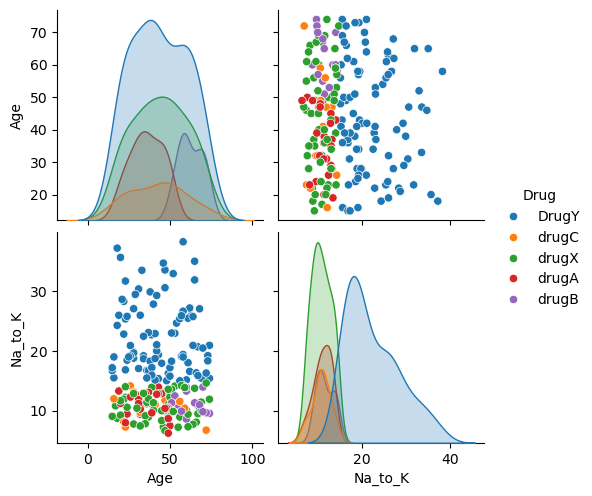

In [ ]:
# Visualization of correlation result with seaborn library pairplot
sns.pairplot(data,hue="Drug");
plt.show()

# hue="Drug" -> all points are colored according to the label in the Drug col
# 1 2 3 4
# 2,3 : scatter plots between feature pairs
# 1,4 : histograms or KDE plots of each feature

In [100]:
# Dataset columns names
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [ ]:
# Checking categories
# Age column
# dropna=False : not to drop NaN values from count
data['Age'].value_counts(dropna=False)

Age
47    8
23    7
28    7
49    7
39    6
32    6
50    5
37    5
58    5
60    5
22    5
34    4
72    4
51    4
42    4
26    4
24    4
74    4
67    4
68    4
61    4
56    4
20    4
36    4
45    4
41    4
31    4
43    4
65    4
57    4
53    3
40    3
70    3
59    3
16    3
38    3
15    3
69    3
35    3
18    3
64    3
52    2
55    2
62    2
19    2
29    2
66    2
73    2
46    2
48    2
54    1
17    1
33    1
63    1
30    1
21    1
25    1
Name: count, dtype: int64

In [105]:
# NatoK column
data["Na_to_K"].value_counts(dropna=False)

Na_to_K
12.006    2
18.295    2
25.355    1
11.939    1
16.347    1
         ..
24.658    1
24.276    1
13.967    1
19.675    1
11.349    1
Name: count, Length: 198, dtype: int64

In [102]:
# Sex column
data["Sex"].value_counts()

Sex
M    104
F     96
Name: count, dtype: int64

In [103]:
# Blood Pressure column
data["BP"].value_counts()

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

In [104]:
# Cholesterol column
data["Cholesterol"].value_counts()

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

In [106]:
# Drug column
data["Drug"].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

## Data Visualization

In [107]:
# Applying plotly library
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# Visualization of Age
# Bar Chart
# .bar(dataframe,row_name,column_name)
dataAge = data['Age'].value_counts(dropna=False)
npar_dataAge = np.array(dataAge) # counts(Number)
x = list(npar_dataAge)
y = data['Age'].value_counts().index # Age
DataAge = {'Age':y,'Number':x}
DataAgedf = pd.DataFrame(DataAge)
fig = px.bar(DataAgedf,x='Age',y='Number')
fig.show()


In [ ]:
# Visualization of Sex
# Figure
#.figure(data) 
    #data:list or tuple of trace instances (Many: [Scatter(),Bar()] / One: Pie())
# graph objects Pie Chart
    # .Pie(labels,values)
# .update_traces() : update properties for all traces(charts) in figure
colors = ['gold','mediumturquoise']
fig = go.Figure(data=[go.Pie(labels=['M','F'],values=[104,96])])
fig.update_traces(hoverinfo='label+percent',textinfo='value',textfont_size=20,marker=dict(colors=colors,line=dict(color='#000000',width=2)))
fig.show()

In [114]:
# Visualization of BP 
# according to value_counts we observed, there are 77 HIGH BP people, 64 Low & 59 normal
fig = px.bar(x=["HIGH","LOW","NORMAL"],y=[77,64,59])
fig.show()

In [ ]:
# histogram : display distribution of data(can only pass col to x: handles binning automatically)
fig = px.histogram(data,x="Age")

In [116]:
# Visualization of Cholesterol
fig = px.histogram(x=["HIGH","NORMAL"],y=[103,97])
fig.show()

In [117]:
# Visualization of Drug
fig = go.Figure(data=[go.Pie(labels=["DrugY","DrugX","DrugA","DrugC","DrugB"],values=[91,54,23,16,16])])
fig.update_traces(hoverinfo='label+percent',textinfo="value",textfont_size=20,marker=dict(colors=px.colors.sequential.RdBu,line=dict(color='#000000',width=2)))
fig.show()

In [120]:
# Visualization of relationship between Age & Na_to_K
fig = px.scatter(data,x="Na_to_K",y="Age",color='Drug',size='Age',hover_data=['Na_to_K'])
fig.show()

## Classification Models

### Data Preparing

In [142]:
# Reload Data for making changes
dataclass = pd.read_csv("./drug200.csv")
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [143]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [144]:
# Changing Object Types 
# Sex
# F:1, M:0
dataclass['Sex'] = [1 if i=='F' else 0 for i in dataclass['Sex']]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,HIGH,HIGH,25.355,DrugY
1,47,0,LOW,HIGH,13.093,drugC
2,47,0,LOW,HIGH,10.114,drugC
3,28,1,NORMAL,HIGH,7.798,drugX
4,61,1,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,LOW,HIGH,11.567,drugC
196,16,0,LOW,HIGH,12.006,drugC
197,52,0,NORMAL,HIGH,9.894,drugX
198,23,0,NORMAL,NORMAL,14.020,drugX


In [145]:
# BP
# LOW:2, NORMAL:1, HIGH:0
import warnings 
warnings.filterwarnings('ignore')
for i in range(len(dataclass['BP'])):
    if dataclass['BP'][i] == "LOW":
        dataclass['BP'][i] = 2
    elif dataclass['BP'][i] == "NORMAL":
        dataclass['BP'][i] = 1
    else:
        dataclass['BP'][i] = 0
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,HIGH,25.355,DrugY
1,47,0,2,HIGH,13.093,drugC
2,47,0,2,HIGH,10.114,drugC
3,28,1,1,HIGH,7.798,drugX
4,61,1,2,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,HIGH,11.567,drugC
196,16,0,2,HIGH,12.006,drugC
197,52,0,1,HIGH,9.894,drugX
198,23,0,1,NORMAL,14.020,drugX


In [146]:
# Cholesterol
# HIGH:1, NORMAL:0
dataclass['Cholesterol'] = [1 if i=='HIGH' else 0 for i in dataclass['Cholesterol']]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,DrugY
1,47,0,2,1,13.093,drugC
2,47,0,2,1,10.114,drugC
3,28,1,1,1,7.798,drugX
4,61,1,2,1,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,1,11.567,drugC
196,16,0,2,1,12.006,drugC
197,52,0,1,1,9.894,drugX
198,23,0,1,0,14.020,drugX


In [147]:
# Drug
# DrugY = 4
# drugX = 3
# drugA = 2
# drugC = 1
# drugB = 0
for i in range(len(dataclass)):
    if dataclass['Drug'][i] == 'DrugY':
        dataclass['Drug'][i] = 4
    elif dataclass['Drug'][i] == 'drugX':
        dataclass['Drug'][i] = 3
    elif dataclass['Drug'][i] == 'drugA':
        dataclass['Drug'][i] = 2
    elif dataclass['Drug'][i] == 'drugC':
        dataclass['Drug'][i] = 1
    else:
        dataclass['Drug'][i] = 0
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,4
1,47,0,2,1,13.093,1
2,47,0,2,1,10.114,1
3,28,1,1,1,7.798,3
4,61,1,2,1,18.043,4
...,...,...,...,...,...,...
195,56,1,2,1,11.567,1
196,16,0,2,1,12.006,1
197,52,0,1,1,9.894,3
198,23,0,1,0,14.020,3


In [148]:
dataclass['Drug'].value_counts()

Drug
4    91
3    54
2    23
1    16
0    16
Name: count, dtype: int64

In [149]:
# Rechecking info to confirm data types 
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


In [150]:
# Changing BP & Drug type as they didn't change automatically
data_types_dict = {'BP':int,'Drug':int}
dataclass = dataclass.astype(data_types_dict)
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [157]:
# Feature 
x_data = dataclass.drop('Drug',axis=1)
# Label
y_data = dataclass['Drug'].values

In [153]:
x_data

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,1,0,1,25.355
1,47,0,2,1,13.093
2,47,0,2,1,10.114
3,28,1,1,1,7.798
4,61,1,2,1,18.043
...,...,...,...,...,...
195,56,1,2,1,11.567
196,16,0,2,1,12.006
197,52,0,1,1,9.894
198,23,0,1,0,14.020


In [158]:
y_data

array([4, 1, 1, 3, 4, 3, 4, 1, 4, 4, 1, 4, 4, 4, 3, 4, 3, 2, 1, 4, 4, 4,
       4, 4, 4, 4, 4, 3, 4, 4, 3, 0, 3, 4, 3, 3, 2, 3, 3, 3, 4, 0, 4, 3,
       3, 3, 2, 1, 4, 4, 4, 3, 4, 4, 0, 1, 0, 4, 3, 4, 4, 2, 4, 3, 0, 4,
       2, 3, 4, 4, 0, 4, 3, 4, 4, 4, 2, 4, 2, 3, 0, 3, 1, 2, 1, 0, 3, 4,
       4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 2, 2, 1, 3, 4, 3, 3, 4, 0, 4,
       2, 3, 3, 3, 3, 4, 3, 3, 2, 4, 4, 4, 4, 4, 0, 4, 4, 3, 4, 3, 4, 4,
       3, 4, 4, 3, 0, 2, 0, 3, 2, 4, 0, 4, 2, 3, 3, 2, 3, 1, 2, 0, 3, 3,
       4, 1, 2, 4, 1, 3, 3, 0, 3, 4, 4, 4, 4, 3, 4, 2, 3, 3, 4, 4, 2, 4,
       2, 4, 4, 4, 4, 3, 3, 4, 4, 4, 0, 2, 4, 4, 4, 2, 4, 1, 4, 1, 1, 3,
       3, 3])

In [160]:
# Split data into training and testing 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=0.3,random_state=1)
print(x_train.shape,x_test.shape)

(140, 5) (60, 5)


### Decision Tree Classifier

In [161]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

# Train
dt_clf = DecisionTreeClassifier()
dt_clf.fit(x_train,y_train)
# Predict
pred = dt_clf.predict(x_test)
# Evaluate
print('The accuracy of Decision Tree is',metrics.accuracy_score(y_test,pred))

The accuracy of Decision Tree is 0.9666666666666667


In [164]:
from sklearn.metrics import accuracy_score
# Decision Tree Classifier with gini
# gini : determine how pure(mostly one class) or impure a node is
    # lower gini : purer node
# Train
dt_clf_gini = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)
dt_clf_gini.fit(x_train,y_train)
# Predict
y_pred_gini = dt_clf_gini.predict(x_test)
# Evaluate
print('Model accuracy score with criterion gini index: {0:0.4f}'.format(accuracy_score(y_test,y_pred_gini)))

Model accuracy score with criterion gini index: 0.9000


In [165]:
y_pred_train_gini = dt_clf_gini.predict(x_train)
y_pred_train_gini

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 3, 4, 3, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 3, 3, 2, 3, 4, 2, 0, 0, 3, 3, 3, 3, 3, 4, 4, 4, 4, 3,
       3, 0, 0, 2, 4, 3, 4, 3, 4, 4, 3, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 3, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4,
       4, 2, 3, 3, 3, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [ ]:
print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_train,y_pred_train_gini)))

Training-set accuracy score: 0.9143


In [167]:
# Print scores on training and test set
print('Training set score: {:.4f}'.format(dt_clf_gini.score(x_train,y_train)))
print('Test set score: {:.4f}'.format(dt_clf_gini.score(x_test,y_test)))

Training set score: 0.9143
Test set score: 0.9000


In [168]:
# Decision Tree Classifier with entropy
# Train
dt_clf_en = DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=0)
dt_clf_en.fit(x_train,y_train)
# Predict
y_pred_en = dt_clf_en.predict(x_test)
print('Model accuracy score with criterion entropy: {0:0.4f}'.format(accuracy_score(y_test,y_pred_en)))

Model accuracy score with criterion entropy: 0.9000


In [169]:
y_pred_train_en = dt_clf_en.predict(x_train)
y_pred_train_en

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 3, 4, 3, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 3, 3, 2, 3, 4, 2, 0, 0, 3, 3, 3, 3, 3, 4, 4, 4, 4, 3,
       3, 0, 0, 2, 4, 3, 4, 3, 4, 4, 3, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 3, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4,
       4, 2, 3, 3, 3, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [170]:
print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.9143


In [171]:
# Print scores on training and test set
print('Training set score: {:.4f}'.format(dt_clf_en.score(x_train, y_train)))
print('Test set score: {:.4f}'.format(dt_clf_en.score(x_test, y_test)))

Training set score: 0.9143
Test set score: 0.9000


### Random Forest Classifier

In [172]:
from sklearn.ensemble import RandomForestClassifier
# Train
rfc = RandomForestClassifier(random_state=0)
rfc.fit(x_train,y_train)
# Predict
predict = rfc.predict(x_test)
# Evaluate
print('Accuracy of Random Forest is',metrics.accuracy_score(predict,y_test))

Accuracy of Random Forest is 0.95


In [173]:
# Random Forest Classifier with n_estimators=100
from sklearn.ensemble import RandomForestClassifier
# Train
rfc_100 = RandomForestClassifier(n_estimators=100,random_state=0)
rfc_100.fit(x_train,y_train)
# Predict
predict = rfc_100.predict(x_test)
print('Accuracy of Random Forest is',metrics.accuracy_score(predict,y_test))

Accuracy of Random Forest is 0.95


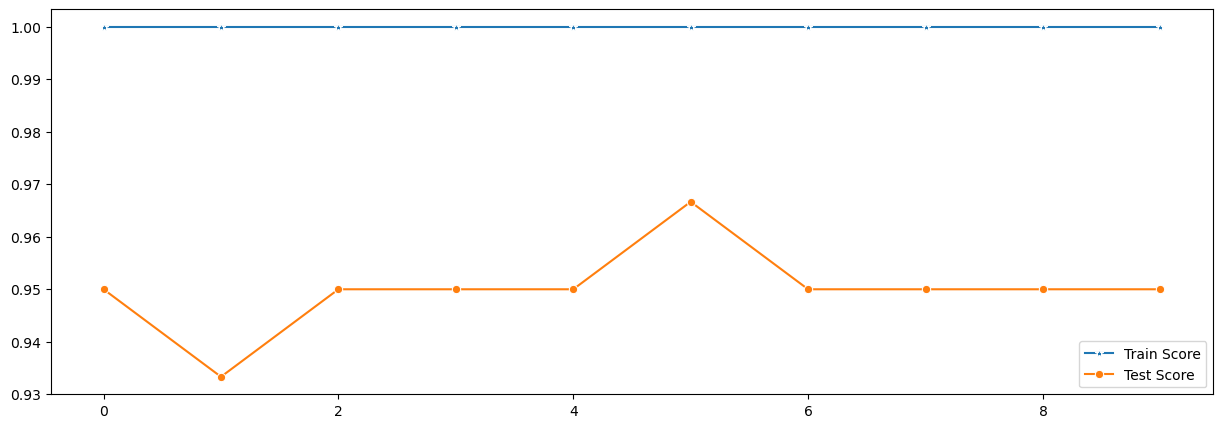

In [ ]:
# Finding best random state value
# .score() for checking % of correct predictions(0.9=90%)
# model.score(X_test, y_test) is shortcut of this : accuracy_score(y_test, model.predict(X_test))
test_score_list = []
train_score_list = []
for i in range(0,10):
    rfc2 = RandomForestClassifier(random_state=i)
    rfc2.fit(x_train,y_train)
    test_score_list.append(rfc2.score(x_test,y_test))
    train_score_list.append(rfc2.score(x_train,y_train))

plt.figure(figsize=(15,5))
sns.lineplot(x=range(0,10),y=train_score_list,marker='*',label='Train Score');
sns.lineplot(x=range(0,10),y=test_score_list,marker='o',label='Test Score');
plt.show()

# 5 -> best random state value

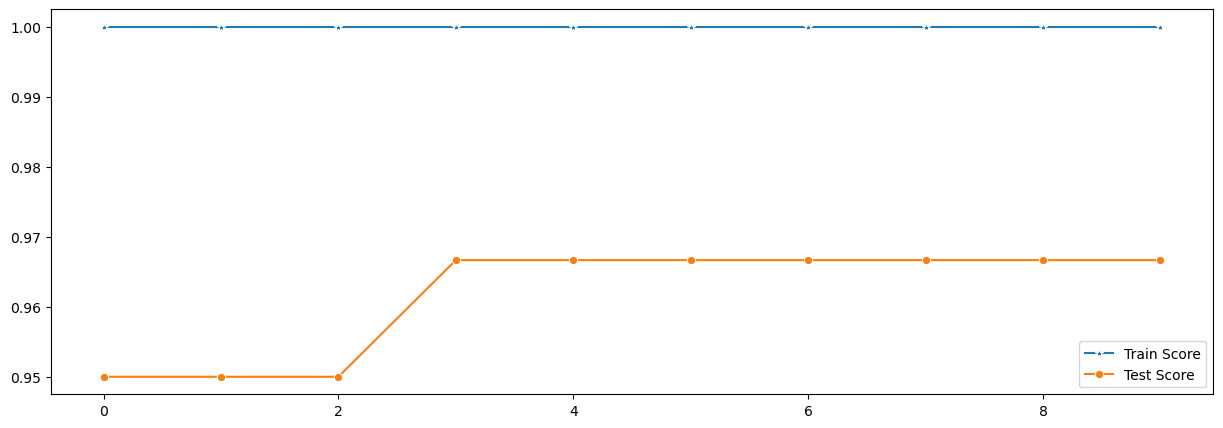

In [ ]:
# Best n_estimators
test_score_list = []
train_score_list = []
list_n_estimators = [10,20,30,40,50,60,70,80,90,100]
for i in range(len(list_n_estimators)):
    rfc3 = RandomForestClassifier(n_estimators=list_n_estimators[i],random_state=5)
    rfc3.fit(x_train,y_train)
    train_score_list.append(rfc3.score(x_train,y_train))
    test_score_list.append(rfc3.score(x_test,y_test))

plt.figure(figsize=(15,5))
sns.lineplot(x=range(0,len(list_n_estimators)),y=train_score_list,marker='*',label='Train Score');
sns.lineplot(x=range(0,len(list_n_estimators)),y=test_score_list,marker='o',label='Test Score');
plt.show()

# best n_estimators : list_n_estimators[3] which is 40 

In [ ]:
last_rfc = RandomForestClassifier(n_estimators=40,random_state=5)
last_rfc.fit(x_train,y_train)
predict = last_rfc.predict(x_test)
print('Accuracy of Random forest is',metrics.accuracy_score(predict,y_test))

Accuracy of Random forest is 0.9666666666666667


In [188]:
y_pred_en = last_rfc.predict(x_test)
print('Model accuracy score with best parameters: {0:.4f}'.format(accuracy_score(y_test,y_pred_en)))

Model accuracy score with best parameters: 0.9667


In [189]:
y_pred_train_en = last_rfc.predict(x_train)

y_pred_train_en

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 1, 4, 1, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 1, 3, 2, 3, 4, 2, 0, 0, 3, 3, 1, 3, 3, 4, 4, 4, 4, 3,
       1, 0, 0, 2, 4, 3, 4, 1, 4, 4, 1, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 1, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 1, 4, 4, 3, 4, 4, 4, 4, 4, 4, 1, 4,
       4, 2, 3, 1, 1, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [190]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 1.0000


In [191]:
# Print scores with best parameters on training and test set

print('Training set score: {:.4f}'.format(last_rfc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(last_rfc.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 0.9667


### Evaluation Classification Models
- Confusion Matrix

In [ ]:
# Confusion Matrix for DecisionTreeClassifier without parameters
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
cm_des = DecisionTreeClassifier()
cm_des.fit(x_train,y_train)
y_pred_cm = cm_des.predict(x_test)
y_true = y_test
cm_des1 = confusion_matrix(y_true,y_pred_cm)
cm_des1

# Meaning of confusion matrix
# 5x5 : 5 different classes
# Rows: actual labels
# columns : predicted labels
# diagonal elements : correct predictions
# off-diagonal : misclassifications
# In this example, 
# 1st row: DrugY predicted 4 instances correctly and misclassified 2 instances as class 2
# 2nd row~5th row: drugX,drugA,drugC,drugB predicted all 4,4,19,27 instances correctly

array([[ 4,  0,  2,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

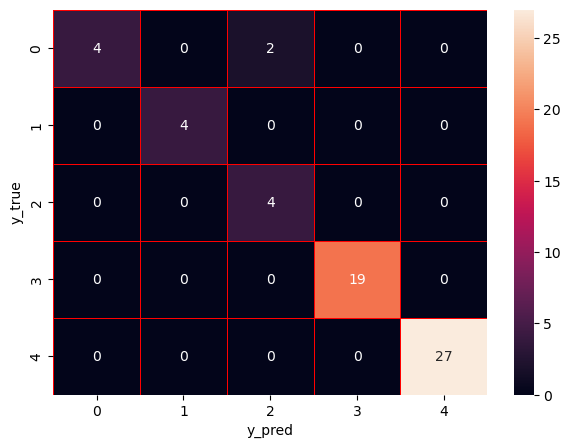

In [194]:
f,ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm_des1,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [195]:
# Confusion matrix for DecisionTreeClassifier with gini
cm_des_gini = DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=0)
cm_des_gini.fit(x_train,y_train)

y_pred_cm = cm_des_gini.predict(x_test)
y_true = y_test

cm_des2 = confusion_matrix( y_true, y_pred_cm)
cm_des2

array([[ 4,  0,  2,  0,  0],
       [ 0,  0,  0,  4,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

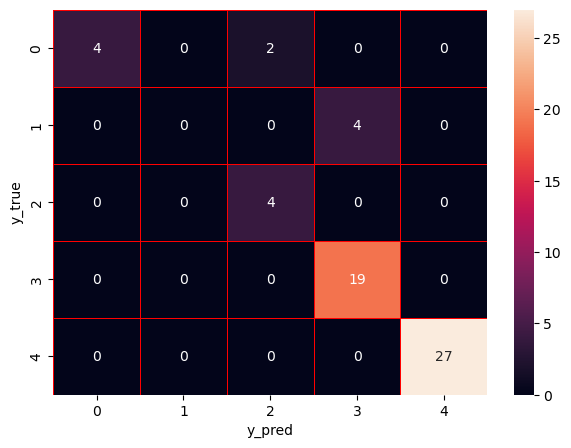

In [196]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des2, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [197]:
# Confusion Matrix for Random Forest Classifier with best parameters
cm_last_rfc = RandomForestClassifier(n_estimators=40,random_state=5)
cm_last_rfc.fit(x_train,y_train)
y_pred_cm = cm_last_rfc.predict(x_test)
y_true = y_test

cm_rfc = confusion_matrix(y_true, y_pred_cm)
cm_rfc

array([[ 4,  0,  2,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

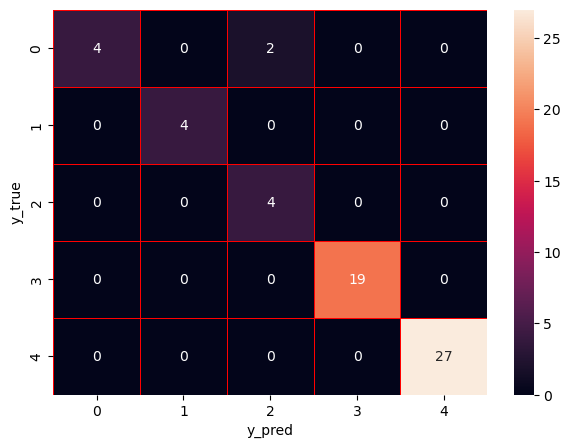

In [198]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_rfc, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

# Beginner Friendly CATBOOST with OPTUNA

## Data

**Attribute Information**

Age: age of the patient [years]

Sex: sex of the patient [M: Male, F: Female]

ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

RestingBP: resting blood pressure [mm Hg]

Cholesterol: serum cholesterol [mm/dl]

FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

ExerciseAngina: exercise-induced angina [Y: Yes, N: No]

Oldpeak: oldpeak = ST [Numeric value measured in depression]

ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]

HeartDisease: output class [1: heart disease, 0: Normal]

## Exploratory Data Analysis

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder, StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

from sklearn.model_selection import KFold, cross_val_predict, train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score,classification_report

# import plotly and cufflinks in offline mode
import cufflinks as cf
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False,world_readable=True)

import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import missingno as msno

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set display
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',900)
pd.set_option('display.max_colwidth',200)

# Load dataset
df = pd.read_csv('./heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info()
# overall data types seems ok

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# Checking duplicated
df.duplicated().sum()
# no duplicates

0

In [11]:
print(df.isnull().sum())
print(df.count())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Age               918
Sex               918
ChestPainType     918
RestingBP         918
Cholesterol       918
FastingBS         918
RestingECG        918
MaxHR             918
ExerciseAngina    918
Oldpeak           918
ST_Slope          918
HeartDisease      918
dtype: int64


In [13]:
# Checking missing data(NaN)
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number,missing_percent],axis=1,keys=['Missing_Number','Missing_Percent'])
    return missing_values

missing(df) 
# No missing values


,Missing_Number,Missing_Percent
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


In [19]:
# .columns : access column names
# select_dtypes : select columns by data type
numerical = df.drop(['HeartDisease'],axis=1).select_dtypes('number').columns
categorical = df.select_dtypes('object').columns
print(f'Numerical columns: {numerical}')
print(f'Categorical Columns: {categorical}')

Numerical columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')
Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [20]:
# nunique() : number of unique values 
df[categorical].nunique()

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

### Target Variable

In [29]:
y = df['HeartDisease']
print(y.value_counts())
# % of class 1 in a target var(HeartDisease)
# normalize : returns proportions 
    # e.g., for class 1, appears 508 times out of 918 
            # 508/(508+410) = 508/918 = 0.55 
y.value_counts(normalize=True)[1]*100

HeartDisease
1    508
0    410
Name: count, dtype: int64


55.33769063180828

In [ ]:
y = df['HeartDisease']
print(f'Percentage of patient had a HeartDisease: {round(y.value_counts(normalize=True)[1]*100,2)}% --> ({y.value_counts()[1]} patient)\n'
      f'Percentage of patient did not have a HeartDisease: {round(y.value_counts(normalize=True)[0]*100,2)}% --> ({y.value_counts()[0]} patient)')

# Almost 55% of patients had a heart disease
# 508 patient had a heart disease
# Almost 45% of patients didn't have a heart disease.
# 410 patient didn't have a heart disease.

Percentage of patient had a HeartDisease: 55.34% --> (508 patient)
Percentage of patient did not have a HeartDisease: 44.66% --> (410 patient)


In [ ]:
df['HeartDisease'].iplot(kind='hist')

# a little imbalance but not much disturbing -> can use 'accuracy' metric as our evaluation metric

### Numerical Features

In [35]:
df[numerical].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000


In [36]:
df[numerical].iplot(kind='hist')

In [ ]:
# bins=50 : divides col into 50 equal width bins
df[numerical].iplot(kind='hist',subplots=True,bins=50)

In [46]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [ ]:
# Detect Skewed Features
skew_limit = 0.75 # threshold for what is considered too skewed
# 0:normal distribution(perfectly symmetrical), >0:right skewed, <0:left skewed
# |skewness|<0.75 (acceptable)
# |skewness|>0.75 (require transformation)
# .skew() : calculate skewness
skew_vals = df[numerical].drop('FastingBS',axis=1).skew()
skew_cols = skew_vals[abs(skew_vals)>skew_limit].sort_values(ascending=False)
skew_cols

# Not much for skewnewss, quite like normal distribution 

Oldpeak    1.022872
dtype: float64

In [ ]:
skew_vals

Oldpeak    1.022872
dtype: float64

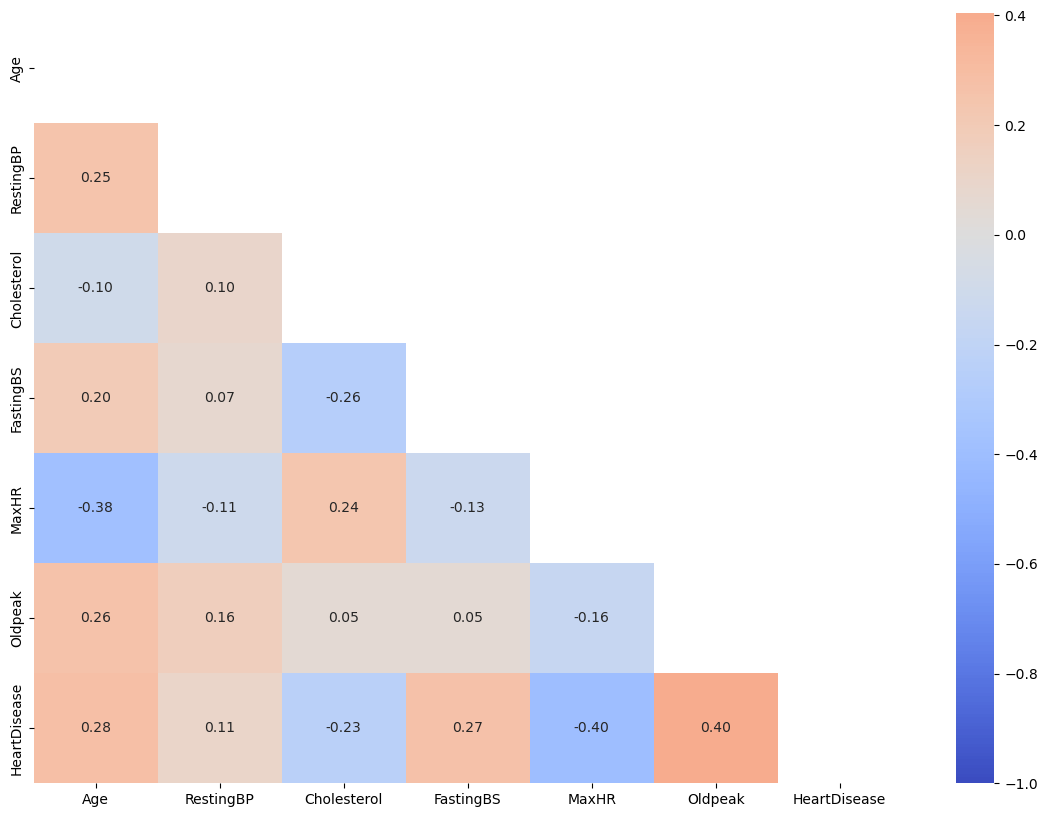

In [ ]:
# Correlation heatmap of numerical features (masking upper triangle to avoid repeating values)
# including HeartDisease
numerical1 = df.select_dtypes('number').columns
# upper triangle
matrix = np.triu(df[numerical1].corr())
fig,ax = plt.subplots(figsize=(14,10))
sns.heatmap(df[numerical1].corr(),annot=True,fmt='.2f',vmin=-1,center=0,cmap='coolwarm',mask=matrix, ax=ax);

# 1:perfect positive correlation(increase-increase), 0:no linear correlation, -1:perfect negative correlation(increase-decrease)
# Based on the matrix, can observe
# weak correlation between numerical features & target var(HeartDisease)
# OldPeak(depression related num) has highest positive cor with heart disease
# MaxHR(maximum heart rate) has highest negative cor with heart disease
# interestingly, cholesterol has negative cor with heart disease

In [52]:
df[numerical].corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000


### Categorical Features

In [62]:
df[categorical].head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [ ]:
# Gender & Heart Disease

print(f'A female person has a probability of {round(df[df["Sex"]=="F"]["HeartDisease"].mean()*100,2)}% have a HeartDisease\n'
      f'A male person has a probability of {round(df[df["Sex"]=="M"]["HeartDisease"].mean()*100,2)}% have a HeartDisease')

A female person has a probability of 25.91% have a HeartDisease
A male person has a probability of 63.17% have a HeartDisease


In [67]:
df[df["Sex"]=="F"]["HeartDisease"][:10]

1     1
3     1
6     0
9     0
10    0
14    0
15    0
17    0
20    0
22    0
Name: HeartDisease, dtype: int64

In [ ]:
fig = px.histogram(df,x="Sex",color="HeartDisease",width=400,height=400)
fig.show()

# Men are almost 2.44(0.6317/0.2591) times more likely to have a heart disease than women

In [75]:
# Chest Pain Type & Heart Disease
df.groupby('ChestPainType')['HeartDisease'].mean().sort_values(ascending=False)


ChestPainType
ASY    0.790323
TA     0.434783
NAP    0.354680
ATA    0.138728
Name: HeartDisease, dtype: float64

In [ ]:
fig = px.histogram(df,x="ChestPainType",color="HeartDisease",width=400,height=400)
fig.show()

# Can observe clear differences among chest pain types.
# Person with ASY(asymptomatic chest pain)has almost 6 times(0.79/0.13) more likely to have a heart disease than person with ATA(atypical angina chest pain)

In [78]:
# RestingECG & Heart Disease
df.groupby('RestingECG')['HeartDisease'].mean().sort_values(ascending=False)

RestingECG
ST        0.657303
LVH       0.563830
Normal    0.516304
Name: HeartDisease, dtype: float64

In [83]:
fig = px.histogram(df,x='RestingECG',color='HeartDisease',width=400,height=400)
fig.show()

# All types show quite similar results
# Person with sT(having ST-T wave abnormality) is more likely to have a heart disease than others

In [84]:
# ExerciseAngina and Heart Disease
df.groupby('ExerciseAngina')['HeartDisease'].mean().sort_values(ascending=False)

ExerciseAngina
Y    0.851752
N    0.351005
Name: HeartDisease, dtype: float64

In [ ]:
fig = px.histogram(df, x="ExerciseAngina", color="HeartDisease",width=400, height=400)
fig.show()

# ExerciseAngina with 'Yes' almost 2.4 times more likely to have a heart disease than 'No'

In [86]:
# ST_Slope & HeartDisease
df.groupby('ST_Slope')['HeartDisease'].mean().sort_values(ascending=False)

ST_Slope
Flat    0.828261
Down    0.777778
Up      0.197468
Name: HeartDisease, dtype: float64

In [ ]:
fig = px.histogram(df, x="ST_Slope", color="HeartDisease",width=400, height=400)
fig.show()

# slope of peak exercise ST segment differ.
# Up significantly less likely to have a heart disease than the other two segments.

**Overall insights from Exploratory Data Analysis**

Target variable is closed to balanced data.

Numerical features have weak correlation with the target variable.

Oldpeak (depression related number) has a positive correlation with the heart disease.

Maximum heart rate has negative correlation with the heart disease.

Interestingly cholesterol has negative correlation with the heart disease.

Based on gender; Men are almost 2.44 times more likely have a heart disease than women.

We can observe clear differences among the chest pain type.
Person with ASY: Asymptomatic chest pain has almost 6 times more likely have a heart disease than person with ATA Atypical Angina chest pain.

RestingECG: resting electrocardiogram results don't differ much.
Person with ST: having ST-T wave abnormality is more likely have a heart disease than the others.

ExerciseAngina: exercise-induced angina with 'Yes' almost 2.4 times more likley have a heart disaese than exercise-induced angina with 'No'

ST_Slope: the slope of the peak exercise ST segment has differences.
ST_Slope Up significantly less likely has heart disease than the other two segment.

## Model Selection

### Baseline Model

In [88]:
accuracy = []
model_names = []

# Feature
X = df.drop('HeartDisease',axis=1)
# Label
y = df['HeartDisease']
# Split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Data Preprocessing
one = OneHotEncoder()
# apply ohe to categorical columns & passes through numeric ones
ct = make_column_transformer((one,categorical),remainder='passthrough')

# Train
# Define
# define dummy classifier that makes constant predictions, always predicts class 1(HeartDisease yes) 
model = DummyClassifier(strategy='constant',constant=1)
# Build pipeline (to combines preprocessing and model into one pipeline)
pipe = make_pipeline(ct,model)
# Fit
pipe.fit(X_train,y_train)

# Predict
y_pred = pipe.predict(X_test)
# Evaluate
score = round(accuracy_score(y_test,y_pred),4)
accuracy.append(score)
print(f'model: {model} and accuracy score is {score}')

model_names.append('DummyClassifier')
# Make into DataFrame
dummy_result_df = pd.DataFrame({'Accuracy':accuracy},index=model_names)
dummy_result_df


model: DummyClassifier(constant=1, strategy='constant') and accuracy score is 0.5942


,Accuracy
DummyClassifier,0.5942


### Logistic & Linear Discriminant SVC & KNN

In [93]:
accuracy = []
model_names = []
# Feature 
X = df.drop('HeartDisease',axis=1)
# Label
y = df['HeartDisease']
# Split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
# Pre-process
ohe = OneHotEncoder()
ct = make_column_transformer((ohe,categorical),remainder='passthrough')
# Define models
lr = LogisticRegression(solver='liblinear')
lda = LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]
for model in models:
    # Make pipeline
    pipe = make_pipeline(ct,model)
    # Fit
    pipe.fit(X_train,y_train)
    # Predict
    y_pred=pipe.predict(X_test)
    score = accuracy.append(round(accuracy_score(y_test,y_pred),4))
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['Logistic','LinearDiscriminant','SVM','KNeighbors']
result_df1 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df1

model : LogisticRegression(solver='liblinear') and  accuracy score is : None
model : LinearDiscriminantAnalysis() and  accuracy score is : None
model : SVC() and  accuracy score is : None
model : KNeighborsClassifier() and  accuracy score is : None


,Accuracy
Logistic,0.8841
LinearDiscriminant,0.8696
SVM,0.7246
KNeighbors,0.7174


### Logistic & Linear Discriminant SVC & KNN with Scaler

In [ ]:
accuracy =[]
model_names =[]

# Feature
X= df.drop('HeartDisease', axis=1)
# Label
y= df['HeartDisease']
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Pre-process
ohe= OneHotEncoder()
s= StandardScaler()
ct1= make_column_transformer((ohe,categorical),(s,numerical))  

# Define models
lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models: 
    # Make pipeline
    pipe = make_pipeline(ct1, model)
    # Fit
    pipe.fit(X_train, y_train)
    # Predict
    y_pred = pipe.predict(X_test)
    # Evaluate
    score = round(accuracy_score(y_test, y_pred),4)
    accuracy.append(score)
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['Logistic_scl','LinearDiscriminant_scl','SVM_scl','KNeighbors_scl']
result_df2 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df2

# with scaler, both KNN & SVM did a better job

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8804
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.8841
model : KNeighborsClassifier() and  accuracy score is : 0.8841


,Accuracy
Logistic_scl,0.8804
LinearDiscriminant_scl,0.8696
SVM_scl,0.8841
KNeighbors_scl,0.8841


### Ensemble Models (AdaBoost & Gradient Boosting & Random Forest & Extra Trees)

In [ ]:
accuracy = []

# Feature
X = df.drop("HeartDisease",axis=1)
# Label
y = df["HeartDisease"]
# Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Preprocess
ohe = OneHotEncoder()
ct = make_column_transformer((ohe,categorical),remainder="passthrough")

# Define models
ada = AdaBoostClassifier(random_state=0)
gb = GradientBoostingClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
et = ExtraTreesClassifier(random_state=0)

models = [ada,gb,rf,et]
for model in models:
    # Make pipeline
    pipe = make_pipeline(ct,model)
    # Fit
    pipe.fit(X_train,y_train)
    # Predict
    y_pred = pipe.predict(X_test)
    # Evaluate
    score = round(accuracy_score(y_test,y_pred),4)
    accuracy.append(score)
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['Ada','Gradient','Random','ExtraTree']
result_df3 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df3

# Accuracy score similar to each other.
# Both random forest and extra tree got similar accuracy score in which both can be improved by hyperparameter tuning


model : AdaBoostClassifier(random_state=0) and  accuracy score is : 0.8659
model : GradientBoostingClassifier(random_state=0) and  accuracy score is : 0.8768
model : RandomForestClassifier(random_state=0) and  accuracy score is : 0.8877
model : ExtraTreesClassifier(random_state=0) and  accuracy score is : 0.8696


,Accuracy
Ada,0.8659
Gradient,0.8768
Random,0.8877
ExtraTree,0.8696


### Famous Trio (XGBoost & LightGBM & Catboost)

In [96]:
accuracy = []

# Feature
X = df.drop("HeartDisease",axis=1)
# Label
y = df["HeartDisease"]
# Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Preprocess
ohe = OneHotEncoder()
ct = make_column_transformer((ohe,categorical),remainder="passthrough")

# Define models
xgbc = XGBClassifier(random_state=0)
lgbmc = LGBMClassifier(random_state=0)

models = [xgbc,lgbmc]
for model in models:
    # Make pipeline
    pipe = make_pipeline(ct,model)
    # Fit
    pipe.fit(X_train,y_train)
    # Predict
    y_pred = pipe.predict(X_test)
    # Evaluate
    score = round(accuracy_score(y_test,y_pred),4)
    accuracy.append(score)
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['XGBoost','LightGBM']
result_df4 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df4



model : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) and  accuracy score is : 0.8478
[LightGBM] [Info] Number of positive: 344, number of negative: 298
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001938 seconds.
You can set `force_row_wise=

,Accuracy
XGBoost,0.8478
LightGBM,0.8732


### CATBOOST

Categorical Boosting
- handles categorical features directly (no need to do encoding)

In [ ]:
accuracy =[]
model_names =[]

X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0)

model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['Catboost_default']
result_df5 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df5

,Accuracy
Catboost_default,0.8804


In [105]:
categorical_features_indices = np.where(X.dtypes != float)[0]
categorical_features_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10])

In [111]:
X.iloc[:5,:]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Catboost HyperParameter Tuning with OPTUNA

In [120]:
def objective(trial):
    X = df.drop('HeartDisease',axis=1)
    y = df['HeartDisease']
    # Select categorical data where they are not float
    categorical_features_indices = np.where(X.dtypes!=float)[0]
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
    # Search Space
    param = {
        # tells CatBoost what loss function to use for binary classification
        "objective": trial.suggest_categorical("objective",["Logloss","CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01,0.1),
        'depth': trial.suggest_int('depth',1,12),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "used_ram_limit": "3gb",
    }
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1)
    # Define model
    cat_cls = CatBoostClassifier(**param)
    # Fit
    cat_cls.fit(X_train,y_train,eval_set=[(X_test,y_test)],cat_features=categorical_features_indices,verbose=0,early_stopping_rounds=100)
    # Predict 
    preds = cat_cls.predict(X_test)
    # rounds predictions to the nearest integer(0 or 1)
    pred_labels = np.rint(preds)
    # Evaluate
    accuracy = accuracy_score(y_test,pred_labels)
    return accuracy

if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))



[I 2025-04-07 02:41:38,342] A new study created in memory with name: no-name-efde3aba-cf2f-4e32-a93b-ce3b7c64b3e1
[I 2025-04-07 02:41:38,884] Trial 0 finished with value: 0.8804347826086957 and parameters: {'objective': 'Logloss', 'colsample_bylevel': 0.056945074485835565, 'depth': 5, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'bagging_temperature': 2.769807863868028}. Best is trial 0 with value: 0.8804347826086957.
[I 2025-04-07 02:41:39,700] Trial 1 finished with value: 0.8913043478260869 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.07660300669365809, 'depth': 1, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS'}. Best is trial 1 with value: 0.8913043478260869.
[I 2025-04-07 02:41:40,431] Trial 2 finished with value: 0.8913043478260869 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.02773297272485089, 'depth': 8, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS'}. Best is trial 1 with value: 0.8913043478260869.
[I 2025-04-

Number of finished trials: 50
Best trial:
  Value: 0.8985507246376812
  Params: 
    objective: Logloss
    colsample_bylevel: 0.054353486236662245
    depth: 9
    boosting_type: Ordered
    bootstrap_type: MVS


In [121]:
accuracy =[]

X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0,objective='Logloss',colsample_bylevel=0.054353486236662245,depth=9,boosting_type='Ordered',bootstrap_type='MVS')
model.fit(X_train,y_train,cat_features=categorical_features_indices,eval_set=(X_test,y_test))

y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test,y_pred),4))
print(classification_report(y_test,y_pred))

model_names = ['CatBoost_tuned']
result_df6 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df6

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       112
           1       0.93      0.90      0.91       164

    accuracy                           0.90       276
   macro avg       0.89      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276



,Accuracy
CatBoost_tuned,0.8986


### Feature Importance

In [123]:
feature_importance = np.array(model.get_feature_importance())
features = np.array(X_train.columns)
fi = {'features':features,'feature_importance':feature_importance}
df_fi = pd.DataFrame(fi)
df_fi.sort_values(by=['feature_importance'],ascending=True,inplace=True)
fig = px.bar(df_fi,x='feature_importance',y='features',title='CatBoost Feature Importance',height=500)
fig.show()

In [122]:
feature_importance = np.array(model.get_feature_importance())
feature_importance 

array([ 6.50244693,  6.63900771, 11.35365107,  5.50167149,  7.81490071,
        7.23558745,  3.43910248,  4.99768833, 10.4797456 , 13.17200326,
       22.86419498])

### Model Comparison

In [ ]:
result_final = pd.concat([dummy_result_df,result_df1,result_df2,result_df3,result_df4,result_df5,result_df6],axis=0)
result_final

,Accuracy
DummyClassifier,0.5942
Logistic,0.8841
LinearDiscriminant,0.8696
SVM,0.7246
KNeighbors,0.7174
Logistic_scl,0.8804
LinearDiscriminant_scl,0.8696
SVM_scl,0.8841
KNeighbors_scl,0.8841
Ada,0.8659


In [127]:
result_final.sort_values(by='Accuracy',ascending=True,inplace=True)
fig = px.bar(result_final,x='Accuracy',y=result_final.index,title='Model Comparison',height=600,labels={'index':'MODELS'})
fig.show()

In [125]:
result_final.index

Index(['DummyClassifier', 'Logistic', 'LinearDiscriminant', 'SVM',
       'KNeighbors', 'Logistic_scl', 'LinearDiscriminant_scl', 'SVM_scl',
       'KNeighbors_scl', 'Ada', 'Gradient', 'Random', 'ExtraTree', 'XGBoost',
       'LightGBM', 'Catboost_default', 'CatBoost_tuned'],
      dtype='object')

**Conclusion (Classification of Heart Disease cases)**
- Made detailed exploratory analysis
- Decided which metric to use
- Analyze Target & Features in detail
- Transform categorical variables into numeric to use them in the model
- Use pipeline to avoid data leakage
- Look at results of each model and selected best one
- Look in detail of Catboost
- Made hyperparameter tuning of Catboost with Optuna to see the improvement
- Look at feature of importance